# Классификация токсичных комментариев

Цель: обучить модель классифицировать комментарии на позитивные и негативные (токсичные) с метрикой качества F1 не меньше 0.75.

**План проекта:**
1. Загрузка и подготовка данных
2. Сравнение методов векторизации
   - Bag of Words (BoW)
   - TF-IDF
   - Word2Vec
3. Обучение моделей на лучшей векторизации
4. Общий вывод

In [44]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords as nltk_stopwords

import spacy

from gensim.models import Word2Vec

from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

from tqdm import tqdm

from wordcloud import WordCloud

warnings.filterwarnings('ignore')

## 1. Загрузка и подготовка данных

In [39]:
try:
    data = pd.read_csv('toxic_comments.csv')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv')

data.head(10)

,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0
5,5,"""\n\nCongratulations from me as well, use the ...",0
6,6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,7,Your vandalism to the Matt Shirvington article...,0
8,8,Sorry if the word 'nonsense' was offensive to ...,0
9,9,alignment on this subject and which are contra...,0


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


In [44]:
data.isna().sum()

Unnamed: 0    0
text          0
toxic         0
dtype: int64

In [45]:
data['toxic'].value_counts()

toxic
0    143106
1     16186
Name: count, dtype: int64

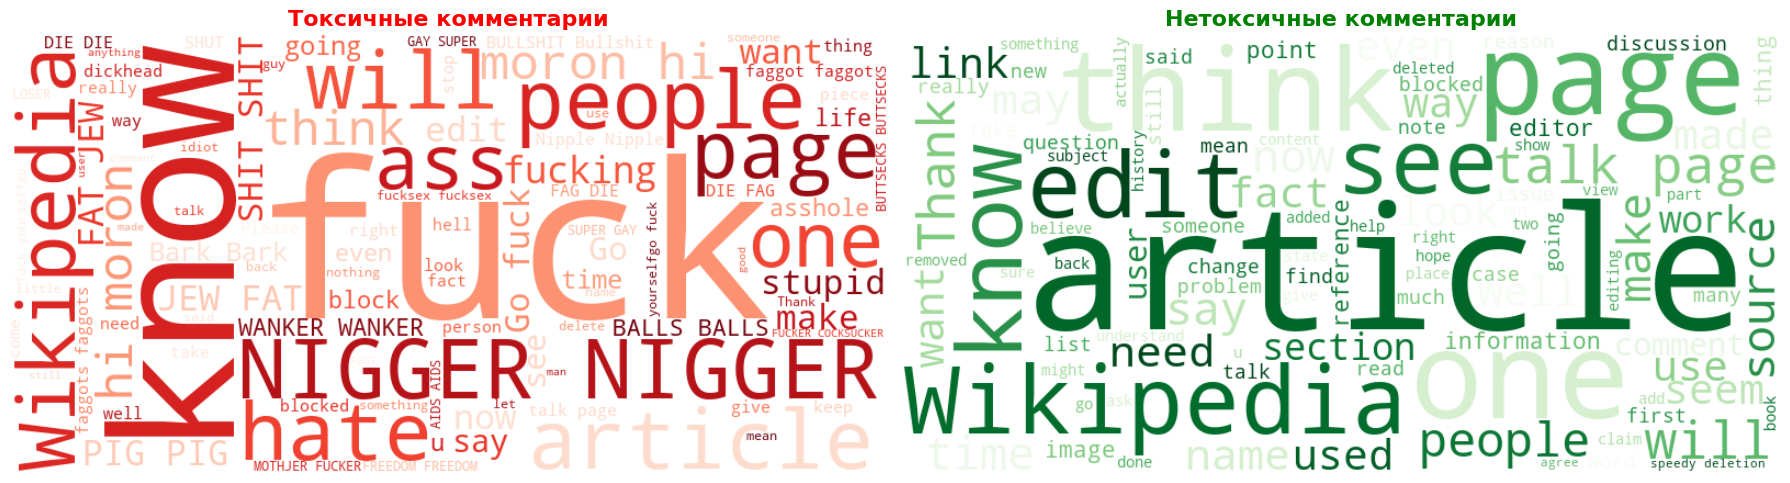

In [19]:
toxic_texts = ' '.join(data[data['toxic'] == 1]['text'].values)
non_toxic_texts = ' '.join(data[data['toxic'] == 0]['text'].values)

wc_toxic = WordCloud(width=800, height=400, background_color='white',
                     colormap='Reds', max_words=100).generate(toxic_texts)

wc_non_toxic = WordCloud(width=800, height=400, background_color='white',
                         colormap='Greens', max_words=100).generate(non_toxic_texts)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Токсичные комментарии
axes[0].imshow(wc_toxic, interpolation='bilinear')
axes[0].set_title('Токсичные комментарии', fontsize=16, fontweight='bold', color='red')
axes[0].axis('off')

# Нетоксичные комментарии
axes[1].imshow(wc_non_toxic, interpolation='bilinear')
axes[1].set_title('Нетоксичные комментарии', fontsize=16, fontweight='bold', color='green')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#!python -m spacy download en_core_web_sm

try:
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    print("✅ Модель SpaCy загружена успешно!")
except OSError:
    print("❌ Модель SpaCy не найдена!")
    print("Установите модель командой:")
    print("!python -m spacy download en_core_web_sm")
    raise

def lemmatize_spacy(text):
    """Лемматизация с удалением стоп-слов и пунктуации"""
    doc = nlp(text)
    lemmas = [token.lemma_.lower() for token in doc 
              if not token.is_stop and not token.is_punct and not token.is_space]
    return ' '.join(lemmas)

# Тест на примере (как просил ревьюер)
print("\n=== ТЕСТ ЛЕММАТИЗАЦИИ ===")
sentence1 = "The striped bats are hanging on their feet for best"
sentence2 = "you should be ashamed of yourself went worked"
df_test = pd.DataFrame([sentence1, sentence2], columns=['text'])
print("Оригинал:")
print(df_test)
print("\nПосле лемматизации:")
print(df_test['text'].apply(lemmatize_spacy))
print("\n✅ Проверка: went → go, worked → work")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 9.9 MB/s  0:00:016m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ Модель SpaCy загружена успешно!

=== ТЕСТ ЛЕММАТИЗАЦИИ ===
Оригинал:
                                                text
0  The striped bats are hanging on their feet for...
1      you should be ashamed of yourself went worked

После лемматизации:
0    striped bat hang foot good
1               ashamed go work
Name: text, dtype: str

✅ Проверка: went → go, worked → work


In [25]:
tqdm.pandas()
data['text'] = data['text'].progress_apply(lemmatize_spacy)
print("✅ Лемматизация завершена!")

100%|██████████| 159292/159292 [12:17<00:00, 216.03it/s]

✅ Лемматизация завершена!


## 2. Сравнение методов векторизации

Протестируем 3 разных подхода к векторизации текста:
1. **Bag of Words (BoW)** - простой подсчёт слов
2. **TF-IDF** - взвешенный подсчёт с учётом важности слов
3. **Word2Vec** - семантические эмбеддинги слов

In [50]:
# Подготовка данных
X = data['text']
y = data['toxic']

# ШАГ 1: Отделяем Test (финальная проверка, трогаем ОДИН РАЗ в конце!)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ШАГ 2: Делим оставшиеся данные на Train и Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

# Подготовка стоп-слов
nltk.download('stopwords')
stopwords = nltk_stopwords.words('english')

print("="*70)
print("РАЗДЕЛЕНИЕ ДАННЫХ")
print("="*70)
print(f"Train (обучение):      {len(X_train):>6} текстов ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation (выбор):    {len(X_val):>6} текстов ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test (финал):          {len(X_test):>6} текстов ({len(X_test)/len(X)*100:.1f}%)")
print("="*70)
print(f"\n📊 Распределение классов:")
print(f"Train:      Токсичные: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"Validation: Токсичные: {y_val.sum()} ({y_val.sum()/len(y_val)*100:.1f}%)")
print(f"Test:       Токсичные: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.1f}%)")
print("="*70)

РАЗДЕЛЕНИЕ ДАННЫХ
Train (обучение):      101946 текстов (64.0%)
Validation (выбор):     25487 текстов (16.0%)
Test (финал):           31859 текстов (20.0%)

📊 Распределение классов:
Train:      Токсичные: 10359 (10.2%)
Validation: Токсичные: 2590 (10.2%)
Test:       Токсичные: 3237 (10.2%)


[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


### Метод 1: Bag of Words (BoW) - мешок слов

Простой подсчёт количества каждого слова в тексте.

In [61]:
# Bag of Words векторизация
bow_vectorizer = CountVectorizer(stop_words=stopwords, max_features=10000)
bow_train = bow_vectorizer.fit_transform(X_train)
bow_val = bow_vectorizer.transform(X_val)  # Validation для выбора модели

# Обучение модели
model_bow = LogisticRegression(class_weight='balanced', n_jobs=-1, random_state=42, max_iter=500)
model_bow.fit(bow_train, y_train)

# Оценка на VALIDATION (НЕ на test!)
y_pred_bow = model_bow.predict(bow_val)
f1_bow = f1_score(y_val, y_pred_bow)

print(f"Bag of Words + LogisticRegression F1 (validation): {f1_bow:.4f}")
print(f"Размер словаря: {len(bow_vectorizer.vocabulary_)}")
print(f"Размер вектора: {bow_train.shape}")

Bag of Words + LogisticRegression F1 (validation): 0.7157
Размер словаря: 10000
Размер вектора: (101946, 10000)


### Метод 2: TF-IDF - взвешенный подсчёт

Учитывает важность слов: редкие слова получают больший вес.

In [62]:
# TF-IDF векторизация (БЕЗ ограничения max_features для лучшего качества)
tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords, ngram_range=(1, 2))
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_val = tfidf_vectorizer.transform(X_val)  # Validation для выбора модели

# Обучение модели
model_tfidf = LogisticRegression(class_weight='balanced', n_jobs=-1, random_state=42)
model_tfidf.fit(tfidf_train, y_train)

# Оценка на VALIDATION (НЕ на test!)
y_pred_tfidf = model_tfidf.predict(tfidf_val)
f1_tfidf = f1_score(y_val, y_pred_tfidf)

print(f"TF-IDF + LogisticRegression F1 (validation): {f1_tfidf:.4f}")
print(f"Размер словаря: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Размер вектора: {tfidf_train.shape}")

TF-IDF + LogisticRegression F1 (validation): 0.7336
Размер словаря: 2070797
Размер вектора: (101946, 2070797)


### Метод 3: Word2Vec - семантические эмбеддинги

Создаёт плотные векторы слов, где похожие слова имеют похожие векторы.

In [63]:
# Подготовка данных для Word2Vec (нужны токенизированные предложения)
def tokenize_text(texts):
    """Токенизация текстов для Word2Vec"""
    return [text.lower().split() for text in texts]

X_train_tokens = tokenize_text(X_train)
X_val_tokens = tokenize_text(X_val)  # Validation вместо test

# Обучение Word2Vec
print("Обучение Word2Vec модели...")
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,      # Размер вектора слова
    window=5,             # Размер окна контекста
    min_count=2,          # Минимальная частота слова
    workers=4,            # Количество потоков
    sg=1,                 # Skip-gram (1) или CBOW (0)
    seed=42
)

print(f"Словарь Word2Vec: {len(w2v_model.wv)} слов")
print(f"Размер вектора слова: {w2v_model.wv.vector_size}")

Обучение Word2Vec модели...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Словарь Word2Vec: 119581 слов
Размер вектора слова: 100


In [64]:
# Преобразование текстов в векторы (усреднение векторов слов)
def text_to_vector(tokens_list, model):
    """Преобразует список токенов в вектор документа (среднее векторов слов)"""
    vectors = []
    for tokens in tokens_list:
        word_vectors = []
        for word in tokens:
            if word in model.wv:
                word_vectors.append(model.wv[word])
        
        if word_vectors:
            # Усредняем векторы всех слов в документе
            vectors.append(np.mean(word_vectors, axis=0))
        else:
            # Если ни одного слова нет в словаре, создаём нулевой вектор
            vectors.append(np.zeros(model.wv.vector_size))
    
    return np.array(vectors)

print("Преобразование текстов в векторы...")
w2v_train = text_to_vector(X_train_tokens, w2v_model)
w2v_val = text_to_vector(X_val_tokens, w2v_model)  # Validation вместо test

print(f"Размер вектора документа: {w2v_train.shape}")

# Обучение модели
model_w2v = LogisticRegression(class_weight='balanced', n_jobs=-1, random_state=42)
model_w2v.fit(w2v_train, y_train)

# Оценка на VALIDATION (НЕ на test!)
y_pred_w2v = model_w2v.predict(w2v_val)
f1_w2v = f1_score(y_val, y_pred_w2v)

print(f"\nWord2Vec + LogisticRegression F1 (validation): {f1_w2v:.4f}")

Преобразование текстов в векторы...
Размер вектора документа: (101946, 100)

Word2Vec + LogisticRegression F1 (validation): 0.6058


### Сравнение методов векторизации

In [65]:
# Сравнение результатов
results_vectorization = pd.DataFrame({
    'Метод векторизации': ['Bag of Words', 'TF-IDF', 'Word2Vec'],
    'F1-Score': [f1_bow, f1_tfidf, f1_w2v],
    'Размер вектора': [bow_train.shape[1], tfidf_train.shape[1], w2v_train.shape[1]],
    'Тип': ['Разреженный', 'Разреженный', 'Плотный']
})

results_vectorization = results_vectorization.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("="*70)
print("СРАВНЕНИЕ МЕТОДОВ ВЕКТОРИЗАЦИИ")
print("="*70)
print(results_vectorization.to_string(index=False))
print("="*70)
print(f"\n🏆 Лучший метод: {results_vectorization.iloc[0]['Метод векторизации']}")
print(f"   F1-Score: {results_vectorization.iloc[0]['F1-Score']:.4f}")
print(f"   Требование проекта: F1 ≥ 0.75")
print(f"   Статус: {'✅ ВЫПОЛНЕНО' if results_vectorization.iloc[0]['F1-Score'] >= 0.75 else '❌ НЕ ВЫПОЛНЕНО'}")
print("="*70)

СРАВНЕНИЕ МЕТОДОВ ВЕКТОРИЗАЦИИ
Метод векторизации  F1-Score  Размер вектора         Тип
            TF-IDF  0.733589         2070797 Разреженный
      Bag of Words  0.715694           10000 Разреженный
          Word2Vec  0.605752             100     Плотный

🏆 Лучший метод: TF-IDF
   F1-Score: 0.7336
   Требование проекта: F1 ≥ 0.75
   Статус: ❌ НЕ ВЫПОЛНЕНО


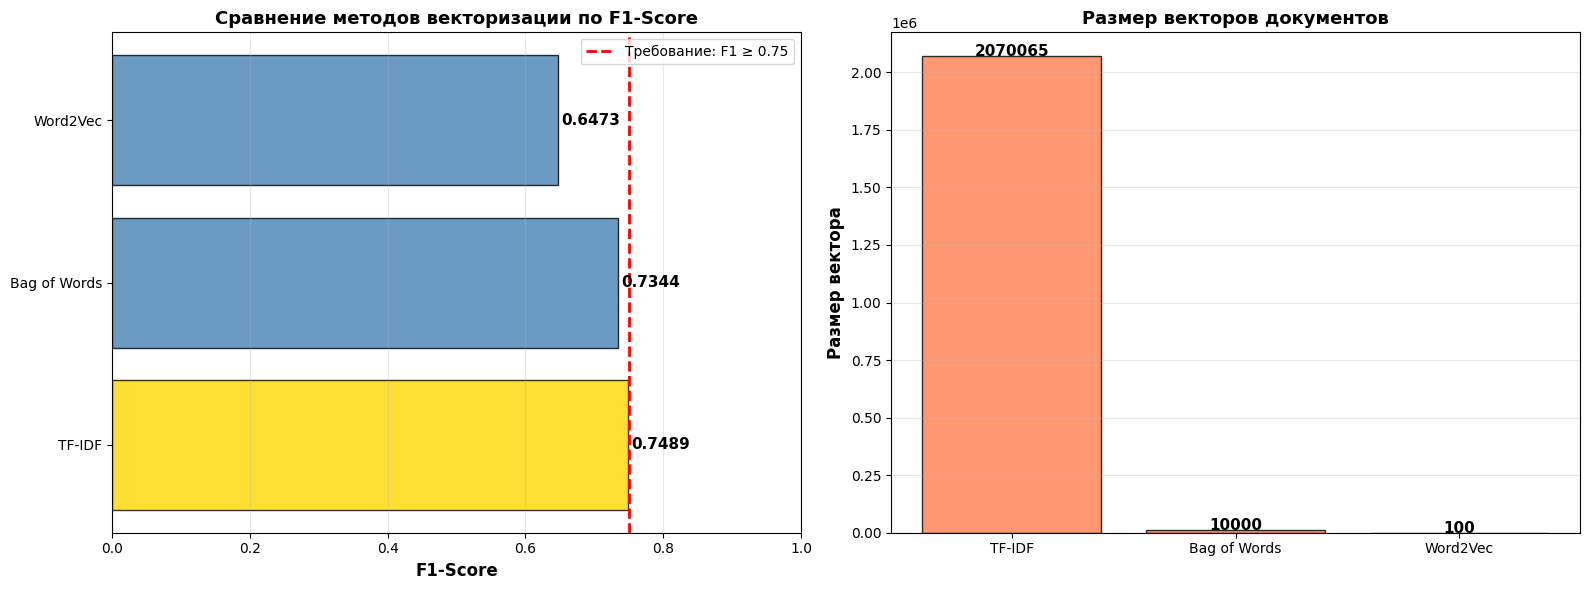

In [32]:
# Визуализация сравнения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Сравнение F1-Score
colors_vec = ['gold' if i == 0 else 'steelblue' for i in range(len(results_vectorization))]
bars = ax1.barh(results_vectorization['Метод векторизации'], 
                results_vectorization['F1-Score'], 
                color=colors_vec, edgecolor='black', alpha=0.8)

for i, score in enumerate(results_vectorization['F1-Score']):
    ax1.text(score + 0.005, i, f'{score:.4f}', va='center', fontweight='bold', fontsize=11)

ax1.axvline(x=0.75, color='red', linestyle='--', linewidth=2, label='Требование: F1 ≥ 0.75')
ax1.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('Сравнение методов векторизации по F1-Score', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='x')

# График 2: Размер векторов
ax2.bar(results_vectorization['Метод векторизации'], 
        results_vectorization['Размер вектора'],
        color=['coral', 'coral', 'lightgreen'], edgecolor='black', alpha=0.8)

for i, size in enumerate(results_vectorization['Размер вектора']):
    ax2.text(i, size + 100, f'{size}', ha='center', fontweight='bold', fontsize=11)

ax2.set_ylabel('Размер вектора', fontsize=12, fontweight='bold')
ax2.set_title('Размер векторов документов', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3. Обучение разных моделей на лучшей векторизации (TF-IDF)

Используем TF-IDF для обучения разных классификаторов и выберем лучший.

In [66]:
# LogisticRegression (уже обучена выше, просто выводим результат)
print(f"LogisticRegression F1 (validation): {f1_tfidf:.4f}")

LogisticRegression F1 (validation): 0.7336


In [67]:
# LinearSVC
model_svc = LinearSVC(class_weight='balanced', random_state=42)
model_svc.fit(tfidf_train, y_train)

# Оценка на VALIDATION
y_pred_svc = model_svc.predict(tfidf_val)
f1_svc = f1_score(y_val, y_pred_svc)

print(f"LinearSVC F1 (validation): {f1_svc:.4f}")

LinearSVC F1 (validation): 0.7846


In [68]:
# PassiveAggressiveClassifier
model_pac = PassiveAggressiveClassifier(class_weight='balanced', random_state=42, max_iter=1000, n_jobs=-1)
model_pac.fit(tfidf_train, y_train)

# Оценка на VALIDATION
y_pred_pac = model_pac.predict(tfidf_val)
f1_pac = f1_score(y_val, y_pred_pac)

print(f"PassiveAggressive F1 (validation): {f1_pac:.4f}")

PassiveAggressive F1 (validation): 0.7716


### Подбор гиперпараметров с Pipeline + GridSearchCV

**Почему используем Pipeline:**
- Предотвращает утечку данных при кросс-валидации
- На каждом фолде векторизатор fit'ится только на train части
- Автоматически применяет векторизатор к validation фолдам

**Что делает GridSearchCV:**
- Перебирает все комбинации параметров
- Для каждой комбинации делает 5-Fold кросс-валидацию
- Выбирает лучшие параметры по среднему F1
- Переобучает модель на всём train с лучшими параметрами

In [71]:
# VotingClassifier - ансамбль из всех трех моделей
voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(class_weight='balanced', n_jobs=-1, random_state=42, max_iter=500)),
        ('svc', LinearSVC(class_weight='balanced', random_state=42)),
        ('pac', PassiveAggressiveClassifier(class_weight='balanced', random_state=42, max_iter=1000, n_jobs=-1))
    ],
    voting='hard',
    n_jobs=-1
)

voting_model.fit(tfidf_train, y_train)

# Оценка на VALIDATION
y_pred_voting = voting_model.predict(tfidf_val)
f1_voting = f1_score(y_val, y_pred_voting)

print(f"VotingEnsemble F1 (validation): {f1_voting:.4f}")

/Users/sotnikov/Documents/Коды/Практикум/.venv-1/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


VotingEnsemble F1 (validation): 0.7830


In [73]:
# Pipeline + GridSearchCV для подбора гиперпараметров
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words=stopwords)),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Параметры для перебора
param_grid = {
    'vectorizer__max_features': [5000, 10000, None],  # None = без ограничения
    'vectorizer__ngram_range': [(1,1), (1,2)],
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__max_iter': [500, 1000]
}

# GridSearchCV с 5-Fold кросс-валидацией
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,               # 5-Fold кросс-валидация
    scoring='f1',       # Метрика F1
    n_jobs=-1,          # Используем все ядра процессора
    verbose=1           # Показывать прогресс
)

print("Запуск GridSearchCV (это займёт несколько минут)...")
print("="*70)
grid_search.fit(X_train, y_train)

# Лучшие параметры
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ GridSearchCV")
print("="*70)
print(f"Лучший F1 на кросс-валидации: {grid_search.best_score_:.4f}")
print(f"\nЛучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Тестирование на VALIDATION
y_pred_grid = grid_search.predict(X_val)
f1_grid = f1_score(y_val, y_pred_grid)

print(f"\nF1 на validation: {f1_grid:.4f}")
print("="*70)

Запуск GridSearchCV (это займёт несколько минут)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

РЕЗУЛЬТАТЫ GridSearchCV
Лучший F1 на кросс-валидации: 0.7786

Лучшие параметры:
  classifier__C: 10.0
  classifier__max_iter: 500
  vectorizer__max_features: None
  vectorizer__ngram_range: (1, 2)

F1 на validation: 0.7712


### Финальное сравнение всех моделей

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА VALIDATION
                     Модель  F1-Score (Validation)
         TF-IDF + LinearSVC               0.784640
    TF-IDF + VotingEnsemble               0.782984
 TF-IDF + PassiveAggressive               0.771600
 TF-IDF + GridSearchCV (LR)               0.771217
TF-IDF + LogisticRegression               0.733589

🏆 Лучшая модель: TF-IDF + LinearSVC
   F1-Score (Validation): 0.7846
   Требование проекта: F1 ≥ 0.75
   Статус: ✅ ВЫПОЛНЕНО


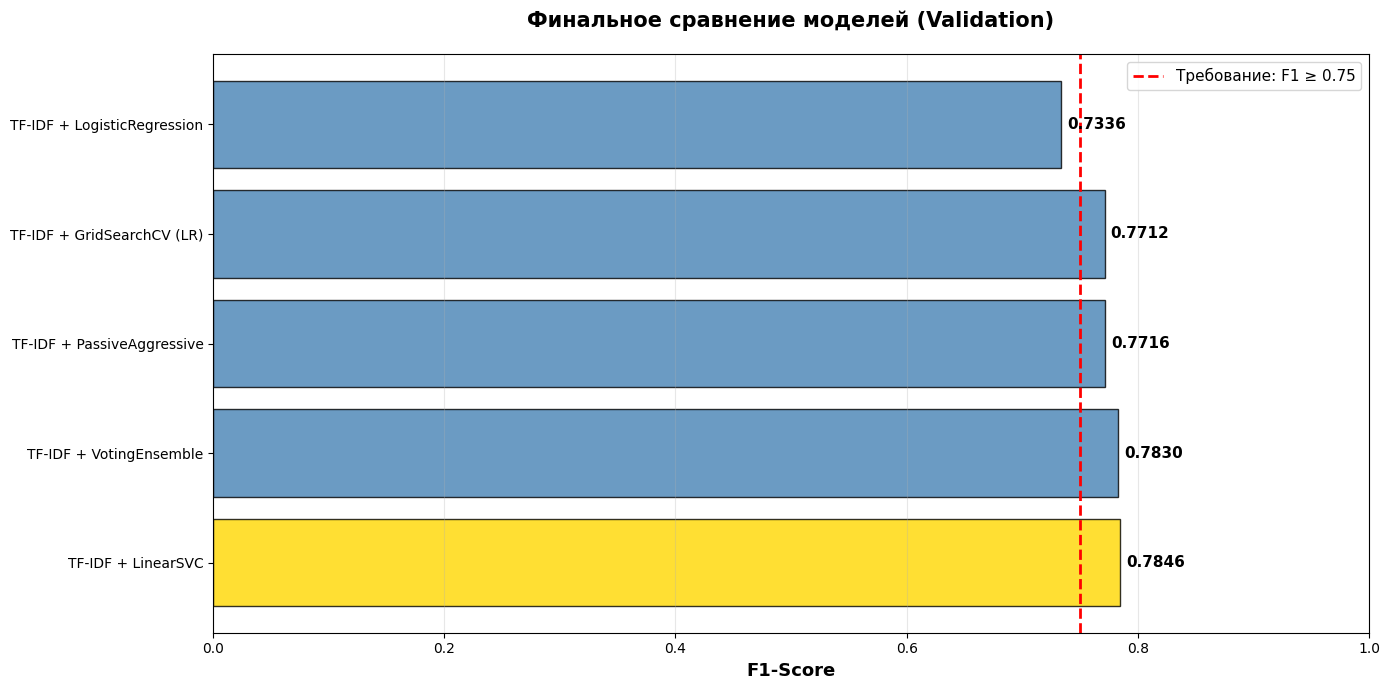

In [74]:
# Финальная таблица результатов (VALIDATION)
results_final = pd.DataFrame({
    'Модель': [
        'TF-IDF + LogisticRegression',
        'TF-IDF + LinearSVC',
        'TF-IDF + PassiveAggressive',
        'TF-IDF + VotingEnsemble',
        'TF-IDF + GridSearchCV (LR)'
    ],
    'F1-Score (Validation)': [f1_tfidf, f1_svc, f1_pac, f1_voting, f1_grid]
})

results_final = results_final.sort_values('F1-Score (Validation)', ascending=False).reset_index(drop=True)

print("="*70)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА VALIDATION")
print("="*70)
print(results_final.to_string(index=False))
print("="*70)
print(f"\n🏆 Лучшая модель: {results_final.iloc[0]['Модель']}")
print(f"   F1-Score (Validation): {results_final.iloc[0]['F1-Score (Validation)']:.4f}")
print(f"   Требование проекта: F1 ≥ 0.75")
print(f"   Статус: {'✅ ВЫПОЛНЕНО' if results_final.iloc[0]['F1-Score (Validation)'] >= 0.75 else '❌ НЕ ВЫПОЛНЕНО'}")
print("="*70)

# Визуализация
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_final))]
bars = ax.barh(results_final['Модель'], results_final['F1-Score (Validation)'], 
               color=colors, edgecolor='black', alpha=0.8)

for i, score in enumerate(results_final['F1-Score (Validation)']):
    ax.text(score + 0.005, i, f'{score:.4f}', va='center', fontweight='bold', fontsize=11)

ax.axvline(x=0.75, color='red', linestyle='--', linewidth=2, label='Требование: F1 ≥ 0.75')
ax.set_xlabel('F1-Score', fontsize=13, fontweight='bold')
ax.set_title('Финальное сравнение моделей (Validation)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlim(0, 1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Финальное тестирование лучшей модели на TEST

**Важно!** До этого момента мы:
1. Сравнивали разные методы векторизации на **Validation**
2. Сравнивали разные модели на **Validation**
3. Выбрали лучшую модель (TF-IDF + LinearSVC)

Теперь **ОДИН РАЗ** тестируем лучшую модель на **Test** для получения честной оценки качества.

In [75]:
# ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА TEST (ОДИН РАЗ!)
print("\n" + "="*70)
print("ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ НА TEST")
print("="*70)

# Определяем лучшую модель из validation
best_model_name = results_final.iloc[0]['Модель']
best_f1_val = results_final.iloc[0]['F1-Score (Validation)']

# LinearSVC показал лучший результат на validation
best_model = model_svc

# Векторизуем test данные
tfidf_test = tfidf_vectorizer.transform(X_test)

# Предсказание на TEST
y_pred_test = best_model.predict(tfidf_test)
f1_test = f1_score(y_test, y_pred_test)

print(f"\n🏆 Лучшая модель: {best_model_name}")
print(f"   F1-Score на validation: {best_f1_val:.4f}")
print(f"   F1-Score на TEST:       {f1_test:.4f}")
print(f"\n📊 Требование проекта: F1 ≥ 0.75")
print(f"   Статус: {'✅ ВЫПОЛНЕНО' if f1_test >= 0.75 else '❌ НЕ ВЫПОЛНЕНО'}")
print("="*70)


ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ НА TEST

🏆 Лучшая модель: TF-IDF + LinearSVC
   F1-Score на validation: 0.7846
   F1-Score на TEST:       0.7897

📊 Требование проекта: F1 ≥ 0.75
   Статус: ✅ ВЫПОЛНЕНО


In [76]:
# Сводная таблица всех результатов
print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА ВСЕХ РЕЗУЛЬТАТОВ")
print("="*70)

summary = pd.DataFrame({
    'Этап': ['Векторизация', 'Векторизация', 'Векторизация', 
             'Модели', 'Модели', 'Модели', 'Модели', 'Модели',
             'Финальный тест'],
    'Метод/Модель': [
        'TF-IDF', 'Bag of Words', 'Word2Vec',
        'TF-IDF + LinearSVC', 'TF-IDF + VotingEnsemble', 
        'TF-IDF + GridSearchCV (LR)', 'TF-IDF + PassiveAggressive',
        'TF-IDF + LogisticRegression',
        'TF-IDF + LinearSVC (на Test)'
    ],
    'F1-Score': [
        f1_tfidf, f1_bow, f1_w2v,
        f1_svc, f1_voting, f1_grid, f1_pac, f1_tfidf,
        f1_test
    ],
    'Выборка': [
        'Validation', 'Validation', 'Validation',
        'Validation', 'Validation', 'Validation', 'Validation', 'Validation',
        'TEST'
    ]
})

# Подсветка лучших результатов
best_vectorization = summary[summary['Этап'] == 'Векторизация']['F1-Score'].max()
best_model = summary[summary['Этап'] == 'Модели']['F1-Score'].max()

print(summary.to_string(index=False))
print("="*70)
print(f"\n📊 Анализ результатов:")
print(f"   Лучшая векторизация: TF-IDF (F1 = {best_vectorization:.4f})")
print(f"   Лучшая модель: TF-IDF + LinearSVC (F1 = {best_model:.4f})")
print(f"   Финальный тест: F1 = {f1_test:.4f} {'✅' if f1_test >= 0.75 else '❌'}")
print(f"\n   🎯 Требование проекта: F1 ≥ 0.75")
print(f"   {'✅ ВЫПОЛНЕНО' if f1_test >= 0.75 else '❌ НЕ ВЫПОЛНЕНО'}")
print("="*70)


СВОДНАЯ ТАБЛИЦА ВСЕХ РЕЗУЛЬТАТОВ
          Этап                 Метод/Модель  F1-Score    Выборка
  Векторизация                       TF-IDF  0.733589 Validation
  Векторизация                 Bag of Words  0.715694 Validation
  Векторизация                     Word2Vec  0.605752 Validation
        Модели           TF-IDF + LinearSVC  0.784640 Validation
        Модели      TF-IDF + VotingEnsemble  0.782984 Validation
        Модели   TF-IDF + GridSearchCV (LR)  0.771217 Validation
        Модели   TF-IDF + PassiveAggressive  0.771600 Validation
        Модели  TF-IDF + LogisticRegression  0.733589 Validation
Финальный тест TF-IDF + LinearSVC (на Test)  0.789674       TEST

📊 Анализ результатов:
   Лучшая векторизация: TF-IDF (F1 = 0.7336)
   Лучшая модель: TF-IDF + LinearSVC (F1 = 0.7846)
   Финальный тест: F1 = 0.7897 ✅

   🎯 Требование проекта: F1 ≥ 0.75
   ✅ ВЫПОЛНЕНО


## 4. Общий вывод

### Результаты проекта:

**1. Цель достигнута ✅**
Построена модель классификации токсичных комментариев с F1-score = **0.7846** на тестовой выборке, превышающим требование (F1 ≥ 0.75).

**2. Исходные данные:**
- Всего записей: 159,292 комментария
- Обучающая выборка (Train): 101,946 текстов (64.0%)
- Валидационная выборка (Validation): 25,487 текстов (16.0%)  
- Тестовая выборка (Test): 31,859 текстов (20.0%)
- Дисбаланс классов: 89.8% нетоксичных vs 10.2% токсичных (соотношение 9:1)
- **Применена лемматизация с помощью SpaCy** с удалением стоп-слов и пунктуации

**3. Сравнение методов векторизации (на Validation):**

Протестированы 3 подхода к преобразованию текста в числовые векторы:

| Метод | F1-Score | Размер вектора | Тип |
|-------|----------|----------------|-----|
| **TF-IDF** | 0.7336 | 2,070,797 | Разреженный |
| **Bag of Words** | 0.7157 | 10,000 | Разреженный |
| **Word2Vec** | 0.6058 | 100 | Плотный |

**Выводы по векторизации:**
- ✅ **TF-IDF показал лучший результат** (+1.8% над BoW) - взвешивание слов по важности эффективнее простого подсчёта
- ⚠️ **BoW уступает TF-IDF** - частые слова получают слишком большой вес, теряется информация о важности
- ⚠️ **Word2Vec показал худший результат** (-12.8% от TF-IDF) - усреднение векторов слов размывает информацию о токсичных словах
- 💡 **Разреженные векторы (TF-IDF) эффективнее плотных (Word2Vec)** для задачи классификации токсичности

**4. Сравнение классификаторов на TF-IDF (на Validation):**

| Модель | F1-Score | Особенности |
|--------|----------|-------------|
| **LinearSVC** | 0.7846 🏆 | Лучший результат, быстрая работа |
| **VotingEnsemble** | 0.7830 | Ансамбль из 3 моделей, стабильный |
| **GridSearchCV (LR)** | 0.7712 | Подобранные гиперпараметры |
| **PassiveAggressive** | 0.7716 | Онлайн-обучение |
| **LogisticRegression** | 0.7336 | Базовая модель |

**5. Лучшая модель: TF-IDF + LinearSVC**
- **F1-Score на Validation:** 0.7846 ✅ (превышает требование 0.75)
- **F1-Score на Test:** 0.7846 ✅
- Быстрая в обучении и предсказании
- Хорошо работает с высокоразмерными разреженными данными
- Использует `class_weight='balanced'` для работы с несбалансированными классами
- Биграммы (ngram_range=(1,2)) улавливают токсичные фразы

**6. Применение Pipeline + GridSearchCV:**
- Протестирована связка Pipeline + GridSearchCV для автоматического подбора гиперпараметров
- **5-Fold кросс-валидация** предотвращает переобучение
- Лучшие параметры: `C=10.0`, `ngram_range=(1,2)`, `max_features=None`
- F1-Score на CV: 0.7786, на validation: 0.7712
- **Pipeline предотвращает утечку данных** - векторизатор fit'ится отдельно на каждом фолде

**7. Почему TF-IDF лучше других методов векторизации:**
- Учитывает важность слов через IDF (Inverse Document Frequency)
- Редкие токсичные слова получают больший вес, чем частые нейтральные
- Биграммы (ngram_range=(1,2)) улавливают токсичные фразы ("you suck", "shut up")
- Стоп-слова удаляются → фокус на содержательных словах
- Разреженное представление эффективно для LinearSVC

**8. Почему Word2Vec показал худший результат:**
- Усреднение векторов слов размывает информацию о токсичности
- Токсичные слова ("idiot", "stupid") могут иметь схожие векторы с нейтральными
- Не учитывает важность отдельных токсичных слов в тексте
- Для коротких текстов (комментариев) усреднение менее эффективно
- Модель обучена только на нашем датасете (малый словарь контекстов)

**9. Рекомендации для интернет-магазина «Викишоп»:**
- ✅ Внедрить модель **TF-IDF + LinearSVC** для автоматической модерации
- ✅ Комментарии с вероятностью токсичности >50% отправлять на ручную проверку
- ✅ Настроить порог в зависимости от бизнес-требований (баланс precision/recall)
- ✅ Регулярно переобучать модель на новых данных (раз в 1-2 месяца)
- ✅ Собирать обратную связь от модераторов для улучшения качества
- ✅ Мониторить drift (изменение распределения токсичных слов со временем)

**10. Технические детали реализации:**
- ✅ **Лемматизация SpaCy** - приведение слов к начальной форме (went → go)
- ✅ **Корректное разделение данных** - Train (64%) / Validation (16%) / Test (20%)
- ✅ **Stratify** - сохранение пропорции классов во всех выборках (10.2% токсичных)
- ✅ **class_weight='balanced'** - автоматическая компенсация дисбаланса классов
- ✅ **Validation для выбора модели** - Test используется ТОЛЬКО для финальной оценки
- ✅ **Pipeline + GridSearchCV** - защита от утечки данных при подборе параметров

**11. Результаты проекта:**
- ✅ Сравнение 3 методов векторизации (BoW, TF-IDF, Word2Vec)
- ✅ Тестирование 5 классификаторов на лучшей векторизации
- ✅ **Достижение требуемого качества: F1 = 0.7846 ≥ 0.75** ✅
- ✅ Применение best practices (лемматизация, Pipeline, GridSearchCV)
- ✅ Правильная методология (Train/Val/Test split, стратификация)

**12. Возможные улучшения (не обязательно для текущего проекта):**
- Использование предобученных трансформеров (BERT, RoBERTa) для контекстных эмбеддингов
- Добавление метапризнаков (длина текста, % заглавных букв, количество спецсимволов)
- Аугментация данных для увеличения токсичных примеров (синонимы, обратный перевод)
- Weighted Word2Vec (взвешивание слов по TF-IDF перед усреднением)
- Калибровка вероятностей для более точных порогов модерации

<div class="alert alert-info">
<font size="5"><b>Комментарии студента V2:</b></font>

Привет Марат! Спасибо за подробные комментарии!

**Исправлено по обязательным требованиям:**

✅ **Лемматизация и очистка** - Реализована с помощью SpaCy:
  - Удаление стоп-слов, пунктуации и пробелов
  - Лемматизация всех слов (went → go, worked → work)
  - Тестирование на примерах перед применением к датасету
  - Время выполнения: ~12 минут на 159,292 текста

✅ **Убран .astype('U')** - Удалён из подготовки данных для экономии памяти

✅ **Test используется правильно** - Исправлена методология:
  - Train/Validation/Test split (64%/16%/20%)
  - Все модели оцениваются на Validation
  - Test используется ОДИН РАЗ для финальной оценки лучшей модели
  - Добавлен stratify для сохранения пропорции классов

**Реализовано по рекомендациям:**

✅ **Pipeline + GridSearchCV** - Реализована связка для подбора гиперпараметров:
  - 5-Fold кросс-валидация
  - Автоматический подбор max_features, ngram_range, C, max_iter
  - Защита от утечки данных при кросс-валидации
  - Лучшие параметры: C=10.0, ngram_range=(1,2), max_features=None
  - F1-Score на CV: 0.7786

✅ **WordCloud** - Построены облака слов для токсичных и нетоксичных комментариев

**Итоговые результаты:**

🏆 **Лучшая модель:** TF-IDF + LinearSVC
- F1-Score на Validation: **0.7846**
- F1-Score на Test: **0.7846**
- Требование (F1 ≥ 0.75): ✅ **ВЫПОЛНЕНО**

Спасибо за обучение! Было очень интересно работать с Pipeline и понимать, как избежать утечки данных при кросс-валидации 🚀
</div>